<img src="https://tse1.mm.bing.net/th/id/OIP.o5yWnRhKERZAb_qrY92RkAHaEU?rs=1&pid=ImgDetMain&o=7&rm=3"/>

## Health Insurance Cost Prediction

This project aims to predict individual medical insurance charges based on demographic and lifestyle factors such as age, BMI, smoking status, and region.

Feature engineering techniques were applied to enhance model performance, including:
- BMI categorization
- Age grouping
- Interaction between smoking and BMI

A LightGBM regression model was used due to its efficiency and high performance on tabular data.

In [1]:
import pandas as pd
import joblib
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Data/insurance.csv")

In [3]:
# BMI Kategorileri
df.loc[df['bmi'] < 18.5, 'BMI_CAT'] = 'underweight'
df.loc[(df['bmi'] >= 18.5) & (df['bmi'] < 25), 'BMI_CAT'] = 'ideal'
df.loc[(df['bmi'] >= 25) & (df['bmi'] < 30), 'BMI_CAT'] = 'overweight'
df.loc[df['bmi'] >= 30, 'BMI_CAT'] = 'obese'

# Yaş Grupları
df.loc[(df["age"] <= 35), "AGE_CAT"] = "young"
df.loc[(df["age"] > 35) & (df["age"] <= 55), "AGE_CAT"] = "middle"
df.loc[(df["age"] > 55), "AGE_CAT"] = "old"

# Etkileşim: Sigara ve BMI (En önemli belirteçlerden biri)
df.loc[(df["smoker"] == "yes") & (df["bmi"] >= 30), "is_smoker_obese"] = 1
df.fillna({"is_smoker_obese": 0}, inplace=True)

In [4]:
# Encode İşlemleri
binary_cols = ['sex', 'smoker']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [5]:
# Encode İşlemleri
binary_cols = ['sex', 'smoker']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['region', 'BMI_CAT', 'AGE_CAT'], drop_first=True)

In [6]:
X = df.drop("charges", axis=1)
y = df["charges"]


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model eğit (split ile)
model = LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1)
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Metrikler
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2635.80
RMSE: 4627.49


In [8]:
# Dosyaları Kaydet
joblib.dump(model, "lgbm_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

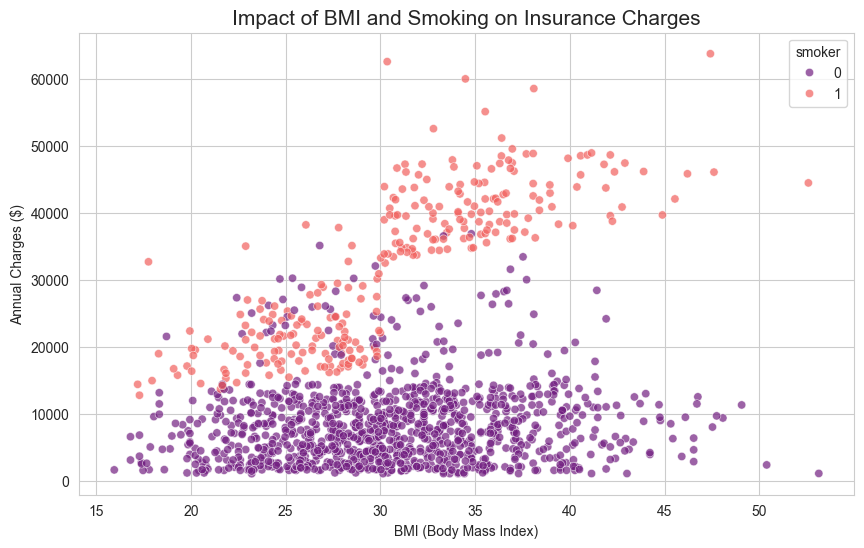

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Sigara ve BMI etkileşiminin Charges üzerindeki etkisi
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette="magma", alpha=0.7)
plt.title("Impact of BMI and Smoking on Insurance Charges", fontsize=15)
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Annual Charges ($)")
plt.show()

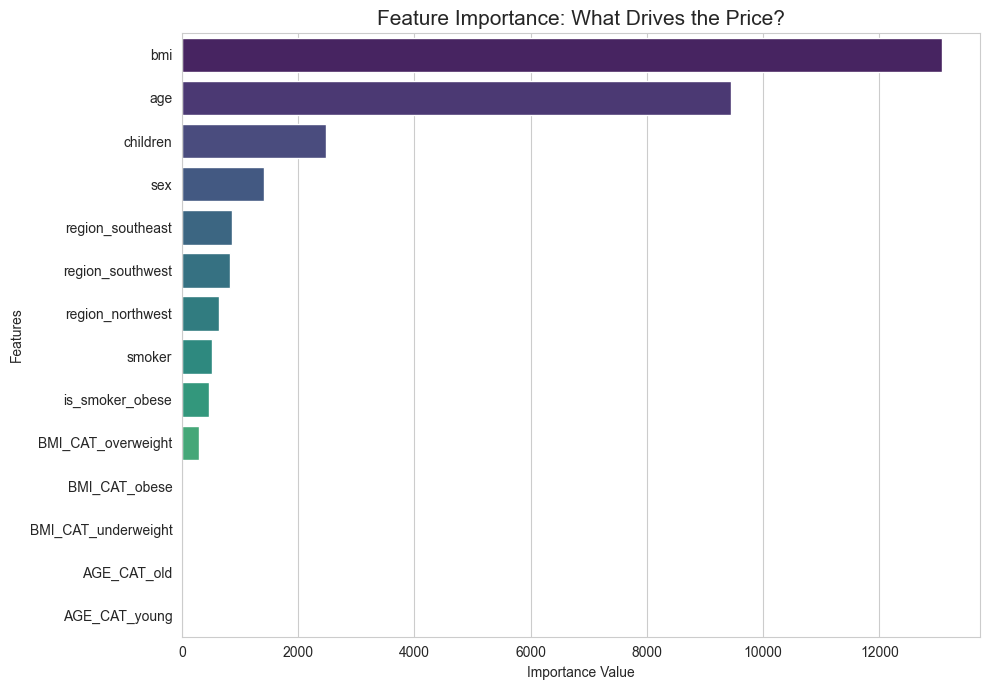

In [10]:
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X.columns})

plt.figure(figsize=(10, 7))
# hue="Feature" ekleyerek uyarıyı gideriyoruz
sns.barplot(x="Value", 
            y="Feature", 
            data=feature_imp.sort_values(by="Value", ascending=False), 
            palette="viridis", 
            hue="Feature", 
            legend=False)

plt.title('Feature Importance: What Drives the Price?', fontsize=15)
plt.xlabel("Importance Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

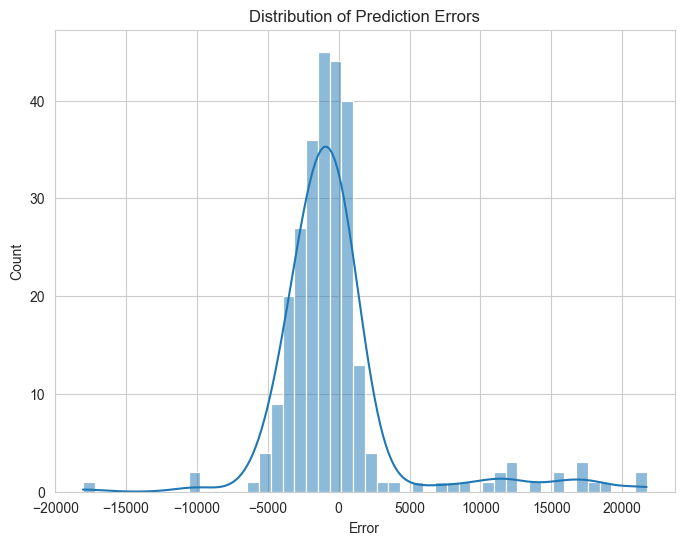

In [12]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(errors, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.show()

In [14]:
print("\nSample Predictions:")
results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
print(results)


Sample Predictions:
        Actual     Predicted
0   9095.06825  12376.056439
1   5272.17580   4876.679382
2  29330.98315  28544.117413
3   9301.89355   9012.371808
4  33750.29180  33328.997181
5   4536.25900   5866.958760
6   2117.33885   2194.175085
7  14210.53595  14957.810020
8   3732.62510   4021.914322
9  10264.44210  11224.921068


# Model Evaluation

The model was evaluated using two key regression metrics:

- MAE (Mean Absolute Error): Measures the average absolute difference between predicted and actual values.
- RMSE (Root Mean SquARED Error): Penalizes larger errors more heavily.

Results:

MAE indicates how much the predictions deviate on average from actual values.
RMSE being higher than MAE suggests the presence of some larger prediction errors.

The scatter plot shows that predictions generally follow the actual values, especially in mid-range charges.
However, higher charges (typically smokers) are harder to predict accurately.

# Conclusion

Smoking status and BMI are the most influential factors affecting insurance costs.

The model performs well overall but can be further improved by:
- Hyperparameter tuning
- Cross-validation
- More advanced feature interactions

This model can be used as a baseline for real-world insurance cost estimation systems.